# Example: Rebalancing Engine and Scorecard on the 2025 Deployment Window

In this example, we turn the Cobb-Douglas allocator from the previous notebook into a production-style engine and measure the edge it produces over passive baselines **on the actual deployment window starting Jan 2 2025**. The synthetic forward paths are replaced here by real daily OHLC for the Session 1 universe: the engine consumes the last 84 trading days of 2024 for the EMA-crossover warmup and then deploys on the first 2025 trading day, so the active window covers 2025 + 2026 YTD including the April 8 2025 tariff-correction drawdown. The engine, the scorecard, and the elasticity sweep together frame the question the Monte Carlo notebook answers by simulating many synthetic futures.

Synthetic Monte Carlo is the right tool for distributional questions, but it does not replace the question every PM ultimately faces: what would this engine have done last year, on the path that actually happened? This example runs the engine on real OHLC data for the Session 1 ticker universe, deploying on Jan 2 2025 with a 2024-tail warmup, and asks whether the rebalancing logic and trigger rules added value over the passive baselines on the one realized future we know to be true.

> __Frictionless tasks, with a stress-test epilogue:__
>
> Tasks 1, 2, and 3 (and the adaptive-η run) all execute trades at mid with **zero transaction costs** so the headline scorecard isolates the allocator and trigger rules from friction. The closing __Stress Test__ section reintroduces transaction costs (sweeping `cost_bps` $\in\{0, 5, 20\}$) alongside $\alpha,\beta$ bootstrap noise so we can read how much of the frictionless edge survives realistic frictions.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
> * __Run a dynamic allocator with production-style triggers:__ Run a dynamic allocator with production-style trigger rules including drawdown limits and turnover caps. Read how the choice of risk thresholds trades off capital protection against participation in recoveries.
> * __Produce a strategy scorecard against passive and risk-free baselines:__ Build a scorecard that compares an active engine to passive and risk-free benchmarks on the same realized prices. Evaluate continuously-compounded growth, volatility, Sharpe ratio, and maximum drawdown to make like-for-like decisions about deployment.
> * __Sweep the CES elasticity axis:__ Sweep the CES substitution elasticity across a discrete grid plus an adaptive variant and compare the resulting wealth trajectories. Identify which end of the elasticity axis rewards conviction versus diversification on the realized path.

Let's dive in!

___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via [the `Include.jl` file](./Include.jl). This activates the local [Julia](https://julialang.org) environment and loads all dependencies.

In [3]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Constants
In the section below, we set some constants that will be used throughout the notebook. We can modify these constants to explore different scenarios and allocations. 

See the comments in the code for more details on each constant, its purpose, units, etc.

In [5]:
# Scorecard configuration
Δt = 1.0 / 252.0              # trading-day step (years)
L_short = 21                  # short EMA window (days) for the sentiment crossover
L_long = 63                   # long EMA window (days) for the sentiment crossover
L_growth = 10                 # EMA window (days) for smoothed market growth rate
GAIN = 10.0                   # gain constant G for the λ sentiment signal
offset = L_short + L_long     # warmup offset before trading begins (days)
B₀ = 10_000.0                 # initial budget (USD)
ALLOCATION_EPSILON = 0.1;      # ε floor for non-preferred assets in the Cobb-Douglas allocator
# n_trading_days is derived from the loaded real price series (total days − offset) and is
# assigned in the data-load cell below, so this constant block doesn't need a year-specific value.

0.1

Load the Session 1 artifacts (`minvar-allocation.jld2`) for the ticker universe, min-var weights, and SIM parameters, then load real OHLC for the same universe plus SPY via [the `MyDeploymentMarketDataSet(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MyDeploymentMarketDataSet), which prepends the last 84 trading days of 2024 (EMA warmup) onto the 2025 + 2026 YTD test data so the engine actually deploys on Jan 2 2025 rather than burning the first 84 days of 2025 on warmup. The market index is SPY's daily close. In the code block below, we assemble and return the following bindings:

* `my_tickers::Vector{String}`: ticker universe loaded from the Session 1 calibration.
* `price_matrix::Matrix{Float64}`: per-ticker close prices with day index in column 1 and per-ticker close in columns 2..N+1.
* `market_prices::Vector{Float64}`: SPY close (market index).
* `lambda_series::Vector{Float64}`: EMA-crossover sentiment signal.
* `gm_ema::Vector{Float64}`: smoothed market growth-rate series.
* `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`: SIM adapter dict (α, β, σ_ε per ticker).
* `allocation_weights::Vector{Float64}`: Session 1 min-var weights.
* `context::MyRebalancingContextModel`: engine context bundled for the rebalancing run.
* `minvar_wealth::Vector{Float64}`: min-var buy-and-hold wealth baseline.
* `equalweight_wealth::Vector{Float64}`: 1/N buy-and-hold wealth baseline.
* `riskfree_wealth::Vector{Float64}`: deterministic risk-free wealth baseline ($B_0 \cdot e^{g_f t}$).
* `g_f::Float64`: continuously compounded risk-free rate.
* `N::Int`: number of tickers.
* `n_trading_days::Int`: number of trading days in the active window.

In [7]:
(; my_tickers, price_matrix, market_prices, lambda_series, gm_ema, sim_params,
   allocation_weights, context, minvar_wealth, equalweight_wealth, riskfree_wealth,
   g_f, N, n_trading_days) = let
    # --- Step 1: Load S1 universe, min-var weights, SIM parameters, risk-free rate ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    my_tickers         = minvar["my_tickers"]::Vector{String};
    sim_estimates      = minvar["sim_estimates"];
    allocation_weights = Float64.(minvar["allocation_weights"]);
    g_f                = Float64(minvar["g_f"]);
    N                  = length(my_tickers);

    sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e ∈ sim_estimates
    );

    # --- Step 2: Load deployment-window OHLC (84-day 2024 tail + 2025 + 2026 YTD) ---
    ds = MyDeploymentMarketDataSet()["dataset"]::Dict{String,DataFrame};
    haskey(ds, "SPY") || error("SPY missing from MyDeploymentMarketDataSet; check data file.");
    market_prices = Float64.(ds["SPY"].close);
    T = length(market_prices);

    # --- Step 3: Build price_matrix [day, 1+k] = close of ticker k on day ---
    price_matrix = zeros(T, N + 1);
    for t ∈ 1:T
        price_matrix[t, 1] = t;
    end
    for (k, ticker) ∈ enumerate(my_tickers)
        haskey(ds, ticker) || error("$(ticker) missing from real dataset.");
        prices = Float64.(ds[ticker].close);
        length(prices) == T || error("$(ticker) has $(length(prices)) days; SPY has $(T).");
        price_matrix[:, k + 1] = prices;
    end

    # --- Step 4: Sentiment signal and smoothed market growth from SPY ---
    ema_s = compute_ema(market_prices; window = L_short);
    ema_l = compute_ema(market_prices; window = L_long);
    lambda_series = compute_lambda(ema_s, ema_l; G = GAIN);

    gm_raw = compute_market_growth(market_prices; Δt = Δt);
    gm_ema = compute_ema(gm_raw; window = L_growth);

    # --- Step 5: Rebalancing context ---
    context = build(MyRebalancingContextModel, (
        B = B₀, tickers = my_tickers, marketdata = price_matrix,
        marketfactor = gm_ema, sim_parameters = sim_params,
        lambda = 0.0, Δt = Δt, epsilon = ALLOCATION_EPSILON,
    ));

    # --- Step 6: Derived trading-day count from real data length ---
    n_trading_days = T - offset;
    buyin_day      = offset + 1;

    # --- Step 7: Baseline wealth trajectories on the same real path ---
    # S1 min-var buy-and-hold: invest allocation_weights at buy-in prices, hold through end.
    p_start  = [price_matrix[buyin_day, k + 1] for k ∈ 1:N];
    shares_mv = B₀ .* allocation_weights ./ p_start;
    minvar_wealth = [sum(shares_mv[k] * price_matrix[t, k + 1] for k ∈ 1:N) for t ∈ buyin_day:T];

    # Equal-weight buy-and-hold.
    eqw_weights = fill(1.0 / N, N);
    shares_eq   = B₀ .* eqw_weights ./ p_start;
    equalweight_wealth = [sum(shares_eq[k] * price_matrix[t, k + 1] for k ∈ 1:N) for t ∈ buyin_day:T];

    # Risk-free deterministic baseline: B₀ · exp(g_f · (t − buyin_day) · Δt).
    riskfree_wealth = [B₀ * exp(g_f * d * Δt) for d ∈ 0:(T - buyin_day)];

    println("Loaded deployment-window OHLC: $(T)-day path (84-day 2024 warmup + 2025 + 2026 YTD) for $(N) tickers + SPY market.")
    println("  Tickers: $(my_tickers)")
    println("  Warmup: $(offset) days   Active: $(n_trading_days) days")
    println("  g_f (continuous, %/yr): $(round(g_f*100, digits=2))")
    println("  SPY start=\$$(round(market_prices[1], digits=2))   SPY end=\$$(round(market_prices[end], digits=2))   SPY return=$(round((market_prices[end]/market_prices[1]-1)*100, digits=2))%")

    (my_tickers = my_tickers, price_matrix = price_matrix, market_prices = market_prices,
     lambda_series = lambda_series, gm_ema = gm_ema, sim_params = sim_params,
     allocation_weights = allocation_weights, context = context,
     minvar_wealth = minvar_wealth, equalweight_wealth = equalweight_wealth,
     riskfree_wealth = riskfree_wealth,
     g_f = g_f, N = N, n_trading_days = n_trading_days)
end;

Loaded deployment-window OHLC: 410-day path (84-day 2024 warmup + 2025 + 2026 YTD) for 22 tickers + SPY market.
  Tickers: ["DIS", "NFLX", "AMZN", "HD", "TJX", "COST", "CVX", "JPM", "V", "MA", "UNH", "LLY", "ABBV", "HON", "CAT", "AAPL", "MSFT", "NVDA", "AVGO", "CRM", "SHW", "AMT"]
  Warmup: 84 days   Active: 326 days
  g_f (continuous, %/yr): 4.5
  SPY start=$552.08   SPY end=$711.21   SPY return=28.82%


### Implementation
We define one helper function used later to compute per-strategy performance metrics for the scorecard table.

> __the `scorecard_metrics(...)` function__
>
> Computes performance metrics from a daily wealth time series in continuously-compounded growth-rate units. Takes a `Vector{Float64}` of daily wealth values and a `String` strategy label, and returns a tuple `(label, total_growth, volatility, sharpe_ratio, max_drawdown)` with growth, volatility, and drawdown expressed as percentages per year. Growth is the annualized CC rate $g = \ln(W_T / W_0) / \Delta t_\text{yr}$ where $\Delta t_\text{yr}$ is the series horizon in years; volatility is the annualized std of daily log returns; Sharpe uses the excess growth over the risk-free benchmark supplied via `rf_growth_pct`.

The helper definition appears in the code cell below.

In [9]:
"""
    scorecard_metrics(wealth::Array{Float64,1}, label::String; rf_growth_pct::Float64 = 0.0) -> Tuple

Compute performance metrics from a daily wealth time series using continuously-compounded growth rates.

### Arguments
- `wealth::Array{Float64,1}`: daily wealth values (e.g., portfolio value over time).
- `label::String`: strategy name used to tag the output row.

### Keyword Arguments
- `rf_growth_pct::Float64`: annualized continuously-compounded risk-free growth rate (%/yr),
   subtracted from the strategy's growth before computing Sharpe. Default `0.0` yields an
   un-risk-adjusted Sharpe.

### Returns
A tuple `(label, total_growth, volatility, sharpe_ratio, max_drawdown)` where growth, volatility,
and max drawdown are expressed as percentages (growth and volatility are in %/yr). Growth is the
annualized CC rate g = ln(W_T / W_0) / Δt_yr; volatility is the annualized std of daily log returns;
Sharpe uses the excess growth over the risk-free benchmark.
"""
function scorecard_metrics(wealth::Array{Float64,1}, label::String; rf_growth_pct::Float64 = 0.0)

    # --- Step 1: Compute daily log returns (CCGR convention) ---
    daily_log_returns = diff(log.(wealth));

    # --- Step 2: Annualized CC growth rate (%/yr): g = ln(W_T / W_0) / horizon_yr ---
    horizon_yr   = (length(wealth) - 1) * Δt;
    total_growth = log(wealth[end] / wealth[1]) / horizon_yr * 100;

    # --- Step 3: Annualized volatility from daily log returns (%/yr) ---
    vol = std(daily_log_returns) * sqrt(252) * 100;

    # --- Step 4: Sharpe on the excess CC growth over the risk-free benchmark ---
    # Guard against deterministic series (e.g. the risk-free curve compounded at constant g_f).
    # std of a constant stream is numerically ~1e-15 rather than exactly zero, so `vol > 0` is
    # not strict enough — we need a tolerance well above FP noise but well below any real
    # asset's annualized vol.
    excess_growth = total_growth - rf_growth_pct;
    sharpe = vol > 1e-6 ? excess_growth / vol : 0.0;

    # --- Step 5: Maximum drawdown (%) ---
    peak = accumulate(max, wealth);
    dd = maximum((peak .- wealth) ./ peak) * 100;

    # --- Step 6: Return rounded metrics ---
    return (label, round(total_growth, digits=2), round(vol, digits=2),
        round(sharpe, digits=2), round(dd, digits=2))
end;

___
## Task 1: Cobb-Douglas Rebalancing Engine with Trigger Rules
In this task, we run the Cobb-Douglas utility allocator inside the full rebalancing engine with our trigger rules: a 15% drawdown limit (circuit breaker) and a 50% turnover cap (trading cost control). We compare three drawdown thresholds to see how the safety net affects performance. *(All runs in this task are frictionless: `cost_bps = 0`. Costs are reintroduced in the Stress Test section.)*

> __What should we see?__
>
> Tighter drawdown limits (10%) cause the engine to de-risk to cash earlier and more often, protecting capital but potentially missing recoveries. Looser limits (25%) allow more volatility. The engine uses Cobb-Douglas utility to decide _how_ to allocate, the trigger rules decide _whether_ to allocate, and the 50% turnover cap bounds _how much_ the book can rotate on any single rebalance, so the per-day share path is smoothed rather than flipping between the $\varepsilon$-floor and full position the way the raw [`BuildCobbDouglasAllocator`](eCornell-AI-Finance-S2-Example-Core-BuildCobbDouglasAllocator-May-2026.ipynb) plot showed.

The code below sweeps three drawdown limits using [the `run_rebalancing_engine(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.run_rebalancing_engine), and the results are stored in the `dd_wealth_curves::Dict{Float64, Array{Float64,1}}` variable.

Baseline max DD = 4.03%
  2% threshold: baseline DD first crosses on day 16;  engine trigger fires on day 16
  3% threshold: baseline DD first crosses on day 16;  engine trigger fires on day 16


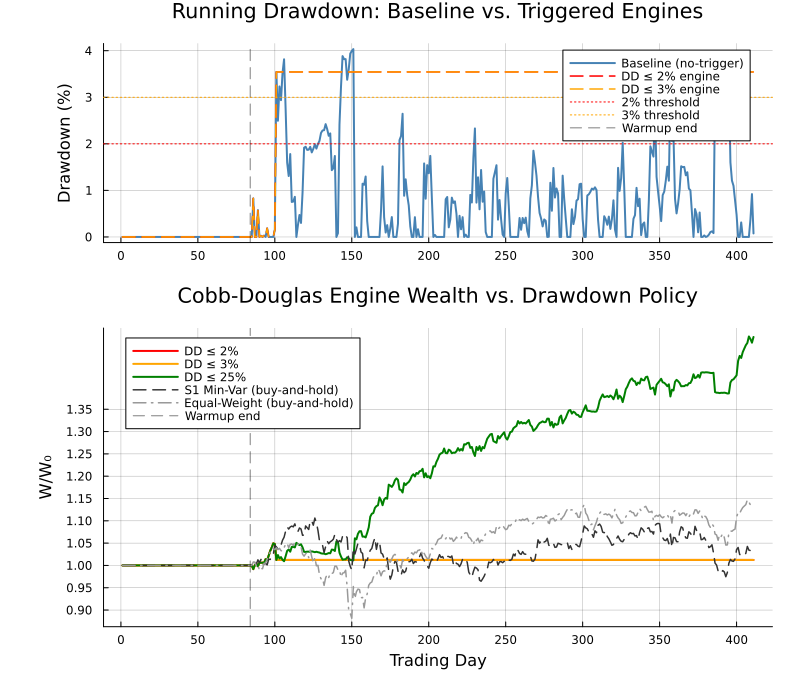

In [11]:
dd_wealth_curves = let
    # --- Step 1: Define drawdown thresholds and plot styling ---
    drawdown_limits = [0.02, 0.03, 0.25];                 # three drawdown trigger levels to compare
    colors          = [:red :orange :green];               # color per threshold
    labels          = ["DD ≤ 2%", "DD ≤ 3%", "DD ≤ 25%"];  # legend labels

    # Storage: maps each drawdown limit to its wealth curve
    dd_wealth_curves = Dict{Float64, Array{Float64,1}}();

    # Helper: prepend flat W₀ values for the warmup window so the x-axis
    # aligns with the Allocator notebook's full 1:T_total market-day axis.
    with_warmup(w) = [fill(B₀, offset); w];

    # --- Step 2: Sweep drawdown limits and store each wealth trajectory ---
    for dd_limit ∈ drawdown_limits
        rules = build(MyTriggerRules, (
            max_drawdown = dd_limit,
            max_turnover = 0.50,
            rebalance_schedule = ones(Int, n_trading_days)  # rebalance every day
        ));
        results = run_rebalancing_engine(context, rules, lambda_series;
            offset = offset, allocator = :cobb_douglas);
        wealth  = compute_wealth_series(results, price_matrix, my_tickers; offset = offset);
        dd_wealth_curves[dd_limit] = wealth;
    end

    # --- Step 3: Running drawdown on each engine's OWN wealth path ---
    running_dd_by = Dict{Float64,Vector{Float64}}();
    for dd_limit ∈ drawdown_limits
        w  = dd_wealth_curves[dd_limit];
        pk = accumulate(max, w);
        running_dd_by[dd_limit] = (pk .- w) ./ pk;
    end
    baseline_dd = running_dd_by[0.25];  # 25% never fires ⇒ identical to a no-trigger run
    max_dd_pct  = round(maximum(baseline_dd) * 100, digits = 2);

    # --- Step 4: Diagnostic — compare baseline DD crossings with engine flatline days ---
    # If the trigger fires correctly, engine first flatlines at (crossing_day + 1).
    println("Baseline max DD = $(max_dd_pct)%")
    for (thr, lbl) ∈ zip([0.02, 0.03], ["2%", "3%"])
        idx_cross = findfirst(x -> x > thr, baseline_dd);
        cross_day = idx_cross === nothing ? nothing : idx_cross - 1;

        w_eng    = dd_wealth_curves[thr];
        idx_flat = findfirst(i -> abs(w_eng[i+1] - w_eng[i]) < 1e-6, 1:length(w_eng)-1);
        # wealth[k+1]==wealth[k] means trading day k is where the engine first holds
        # (so the trigger fired on trading day k-1).
        trigger_day = idx_flat === nothing ? nothing : idx_flat - 1;

        c = cross_day === nothing ? "never"      : "day $(cross_day)";
        t = trigger_day === nothing ? "never"    : "day $(trigger_day)";
        println("  $(lbl) threshold: baseline DD first crosses on $(c);  engine trigger fires on $(t)")
    end

    # --- Step 5: Top panel — running DD for baseline AND each triggered engine ---
    p_top = plot(ylabel = "Drawdown (%)",
        title = "Running Drawdown: Baseline vs. Triggered Engines",
        legend = :topright,
        xticks = 0:50:450, yticks = 0:1:5,
        grid = true, gridalpha = 0.3,
        left_margin = 10Plots.mm, right_margin = 5Plots.mm,
        top_margin = 3Plots.mm, bottom_margin = 3Plots.mm)
    plot!(p_top, 1:(offset + length(baseline_dd)), [zeros(offset); baseline_dd] .* 100,
        label = "Baseline (no-trigger)", linewidth = 2, color = :steelblue)
    for (j, dd_limit) ∈ enumerate([0.02, 0.03])
        rdd      = running_dd_by[dd_limit];
        dd_full  = [zeros(offset); rdd];
        plot!(p_top, 1:length(dd_full), dd_full .* 100,
            label = "$(labels[j]) engine", linewidth = 1.5, color = colors[j], linestyle = :dash)
    end
    hline!(p_top, [2.0], linestyle = :dot, color = :red,    label = "2% threshold")
    hline!(p_top, [3.0], linestyle = :dot, color = :orange, label = "3% threshold")
    vline!(p_top, [offset], linestyle = :dash, color = :black, alpha = 0.5, label = "Warmup end")

    # --- Step 6: Bottom panel — W/W₀ curves for each engine run plus the two baselines ---
    p_bot = plot(xlabel = "Trading Day", ylabel = "W/W₀",
        title = "Cobb-Douglas Engine Wealth vs. Drawdown Policy",
        legend = :topleft,
        xticks = 0:50:450, yticks = 0.85:0.05:1.35,
        grid = true, gridalpha = 0.3,
        left_margin = 10Plots.mm, right_margin = 5Plots.mm,
        top_margin = 3Plots.mm, bottom_margin = 6Plots.mm)
    for (j, dd_limit) ∈ enumerate(drawdown_limits)
        w_full = with_warmup(dd_wealth_curves[dd_limit]);
        plot!(p_bot, 1:length(w_full), w_full ./ B₀, label = labels[j], linewidth = 2, color = colors[j])
    end
    mv_full  = with_warmup(minvar_wealth);
    eqw_full = with_warmup(equalweight_wealth);
    plot!(p_bot, 1:length(mv_full), mv_full ./ B₀,
        label = "S1 Min-Var (buy-and-hold)", linewidth = 1.5, color = :gray20, linestyle = :dash)
    plot!(p_bot, 1:length(eqw_full), eqw_full ./ B₀,
        label = "Equal-Weight (buy-and-hold)", linewidth = 1.5, color = :gray60, linestyle = :dashdot)
    vline!(p_bot, [offset], linestyle = :dash, color = :black, alpha = 0.5, label = "Warmup end")

    # --- Step 7: Combine panels and render ---
    p_combined = plot(p_top, p_bot, layout = grid(2, 1, heights = [0.40, 0.60]), size = (800, 700))
    display(p_combined)
    dd_wealth_curves
end;

___
## Task 2: Scorecard, Engine vs. Baselines
In this task, we produce a scorecard comparing three strategies: the AI Cobb-Douglas engine (DD $\leq$ 15%, $\tau \leq$ 50%), equal-weight buy-and-hold, and risk-free. The scorecard tracks return, volatility, Sharpe ratio, and maximum drawdown. *(Frictionless run: `cost_bps = 0`. The Stress Test section at the end of the notebook revisits this scorecard under realistic transaction costs.)*

> __What should we see?__
>
> The engine should show better risk-adjusted performance (lower drawdown, potentially better Sharpe) than static allocations, at the cost of higher trading activity. The scorecard quantifies exactly how much adaptability costs and what it buys.

In the code block below, we run the engine via [the `run_rebalancing_engine(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.run_rebalancing_engine), compute per-strategy metrics, print the scorecard, and return `engine_wealth::Vector{Float64}` (the AI engine's daily wealth trajectory) for use in downstream plots.

In [13]:
engine_wealth = let
    # --- Step 1: Run the moderate engine configuration (DD ≤ 15%, τ ≤ 50%) ---
    rules = build(MyTriggerRules, (
        max_drawdown = 0.15, max_turnover = 0.50,
        rebalance_schedule = ones(Int, n_trading_days)
    ));
    results = run_rebalancing_engine(context, rules, lambda_series;
        offset=offset, allocator=:cobb_douglas);
    engine_wealth = compute_wealth_series(results, price_matrix, my_tickers; offset=offset);

    # --- Step 2: Risk-free annualized CC growth rate (for excess-growth Sharpe) ---
    rf_horizon_yr = (length(riskfree_wealth) - 1) * Δt;
    rf_growth_pct = log(riskfree_wealth[end] / riskfree_wealth[1]) / rf_horizon_yr * 100;

    # --- Step 3: Compute metrics for each strategy ---
    rf_label = "Risk-Free ($(round(g_f*100, digits=2))%)";
    eng = scorecard_metrics(engine_wealth,      "Cobb-Douglas Engine (DD≤15%, τ≤50%)"; rf_growth_pct = rf_growth_pct);
    mv  = scorecard_metrics(minvar_wealth,      "S1 Min-Var (buy-and-hold)";            rf_growth_pct = rf_growth_pct);
    eqw = scorecard_metrics(equalweight_wealth, "Equal-Weight (buy-and-hold)";          rf_growth_pct = rf_growth_pct);
    rf  = scorecard_metrics(riskfree_wealth,    rf_label;                               rf_growth_pct = rf_growth_pct);

    # --- Step 4: NPV of terminal wealth, discounted at the risk-free rate, scaled by W₀ ---
    # Each wealth series has its own horizon (length − 1 trading steps), so discount per-series
    # to keep the risk-free row exactly zero (it's compounded and discounted over the same span).
    npv_ratio(w) = (w[end] * exp(-g_f * (length(w) - 1) * Δt) - w[1]) / w[1];

    # --- Step 5: Build and display the scorecard table ---
    scorecard = DataFrame(
        "Strategy"         => [eng[1], mv[1], eqw[1], rf[1]],
        "Growth (%/yr)"    => [eng[2], mv[2], eqw[2], rf[2]],
        "Volatility (%/yr)"=> [eng[3], mv[3], eqw[3], rf[3]],
        "Sharpe Ratio"     => [eng[4], mv[4], eqw[4], rf[4]],
        "Max Drawdown (%)" => [eng[5], mv[5], eqw[5], rf[5]],
        "NPV/W₀"           => [round(npv_ratio(engine_wealth),      digits=4),
                                round(npv_ratio(minvar_wealth),      digits=4),
                                round(npv_ratio(equalweight_wealth), digits=4),
                                round(npv_ratio(riskfree_wealth),    digits=4)]
    );

    println("═"^70)
    println("  SESSION 2 SCORECARD: Cobb-Douglas Engine vs. S1 + Baselines")
    println("═"^70)
    pretty_table(scorecard; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # --- Step 6: Save results for downstream sessions ---
    save_results(joinpath(_PATH_TO_DATA, "session2-scorecard.jld2"), Dict(
        "scorecard"          => scorecard,
        "engine_wealth"      => engine_wealth,
        "minvar_wealth"      => minvar_wealth,
        "equalweight_wealth" => equalweight_wealth,
        "riskfree_wealth"    => riskfree_wealth,
    ));
    engine_wealth
end;

══════════════════════════════════════════════════════════════════════
  SESSION 2 SCORECARD: Cobb-Douglas Engine vs. S1 + Baselines
══════════════════════════════════════════════════════════════════════
 ------------------------------------- --------------- ------------------- -------------- ------------------ ---------
                             Strategy   Growth (%/yr)   Volatility (%/yr)   Sharpe Ratio   Max Drawdown (%)    NPV/W₀ 
                               String         Float64             Float64        Float64            Float64   Float64 
 ------------------------------------- --------------- ------------------- -------------- ------------------ ---------
  Cobb-Douglas Engine (DD≤15%, τ≤50%)           31.96               11.87           2.31               4.03    0.4265
            S1 Min-Var (buy-and-hold)            2.99               16.18          -0.09               12.8   -0.0193
          Equal-Weight (buy-and-hold)           10.54               15.77           

The code below plots the wealth curves for all four strategies (engine, S1 min-var, equal-weight, risk-free) on a single axis.

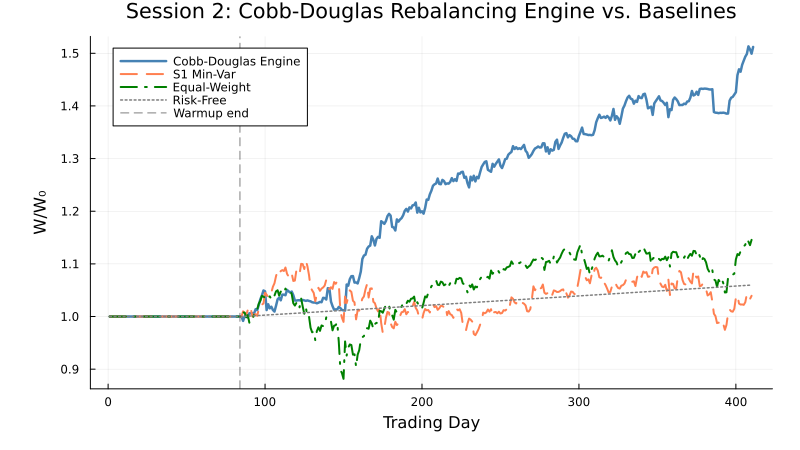

In [15]:
let
    # --- Step 1: Prepend the warmup window (flat at B₀) so all curves share the market-day axis ---
    with_warmup(w) = [fill(B₀, offset); w];
    engine_full = with_warmup(engine_wealth);
    mv_full     = with_warmup(minvar_wealth);
    eqw_full    = with_warmup(equalweight_wealth);
    rf_full     = with_warmup(riskfree_wealth);

    # --- Step 2: Plot each strategy on the full market-day axis (scaled by B₀) ---
    p = plot(1:length(engine_full), engine_full ./ B₀,
        label="Cobb-Douglas Engine", linewidth=2.5, color=:steelblue)
    plot!(p, 1:length(mv_full),  mv_full  ./ B₀, label="S1 Min-Var",   linewidth=2,   color=:coral,  linestyle=:dash)
    plot!(p, 1:length(eqw_full), eqw_full ./ B₀, label="Equal-Weight", linewidth=2,   color=:green,  linestyle=:dashdot)
    plot!(p, 1:length(rf_full),  rf_full  ./ B₀, label="Risk-Free",    linewidth=1.5, color=:gray50, linestyle=:dot)
    vline!(p, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)

    # --- Step 3: Axis labels, margins, and formatting ---
    xlabel!(p, "Trading Day")
    ylabel!(p, "W/W₀")
    title!(p, "Session 2: Cobb-Douglas Rebalancing Engine vs. Baselines")
    plot!(p, size=(800, 450), legend=:topleft,
        left_margin = 10Plots.mm, right_margin = 5Plots.mm,
        top_margin = 3Plots.mm, bottom_margin = 6Plots.mm)
    p
end

___
## Task 3: CES Elasticity Sweep: How Concentration Tunes Engine Behavior
In this task, we swap the allocator inside the rebalancing engine from Cobb-Douglas to CES utility and run the engine at four elasticity values: $\eta \in \{0.5, 1.0, 2.0, 3.0\}$. CES with $\eta = 1$ is the Cobb-Douglas limit (same allocation, same wealth path); $\eta > 1$ concentrates more budget in the single best-scoring asset, $\eta < 1$ diversifies more aggressively. By holding trigger rules and sentiment fixed, the η sweep isolates the effect of *how much* the allocator reacts to its own preference weights. *(Still frictionless: `cost_bps = 0` across all η values. The Stress Test section sweeps cost separately.)*

> __What should we see?__
>
> The $\eta = 1$ CES run should overlay the Cobb-Douglas engine almost exactly (they're the same allocation; the matching is a sanity check on the library's CES path). As $\eta$ grows, wealth trajectories diverge from Cobb-Douglas: high-$\eta$ runs place larger bets on the top-γ asset each day, which amplifies upside in trending regimes and downside in choppy ones. Low-$\eta$ runs look smoother but typically underperform because they spread budget even across weakly-preferred assets.

In the code block below, we run the rebalancing engine four times (once per η value), each with the same trigger rules (DD ≤ 15%, τ ≤ 50%) and the same $\lambda$ series from Task 1. The per-η wealth series are stored in the `ces_wealth_curves::Dict{Float64,Vector{Float64}}` dictionary.

In [17]:
ces_wealth_curves = let
    # --- Step 1: Define the η grid ---
    # η = 1 is the Cobb-Douglas limit (sanity check row).
    η_values = [0.5, 1.0, 2.0, 3.0];

    # --- Step 2: Trigger rules and sentiment shared across all runs ---
    rules = build(MyTriggerRules, (
        max_drawdown = 0.15, max_turnover = 0.50,
        rebalance_schedule = ones(Int, n_trading_days)
    ));

    # --- Step 3: Run the engine once per η and store the wealth series ---
    ces_wealth_curves = Dict{Float64, Vector{Float64}}();
    for η ∈ η_values
        results_η = run_rebalancing_engine(context, rules, lambda_series;
            offset = offset, allocator = :ces, eta = η);
        wealth_η  = compute_wealth_series(results_η, price_matrix, my_tickers; offset = offset);
        ces_wealth_curves[η] = wealth_η;
    end

    println("CES engine runs complete for η ∈ $(η_values)")
    for η ∈ η_values
        w = ces_wealth_curves[η];
        println("  η=$(η):  W/W₀ final = $(round(w[end]/B₀, digits=3)),  max = $(round(maximum(w)/B₀, digits=3))")
    end
    ces_wealth_curves
end;

CES engine runs complete for η ∈ [0.5, 1.0, 2.0, 3.0]
  η=0.5:  W/W₀ final = 1.479,  max = 1.479
  η=1.0:  W/W₀ final = 1.512,  max = 1.513
  η=2.0:  W/W₀ final = 1.63,  max = 1.64
  η=3.0:  W/W₀ final = 1.741,  max = 1.776


The code below plots the four CES wealth trajectories on a single axis, with the Cobb-Douglas engine and the S1 min-var baseline as reference lines.

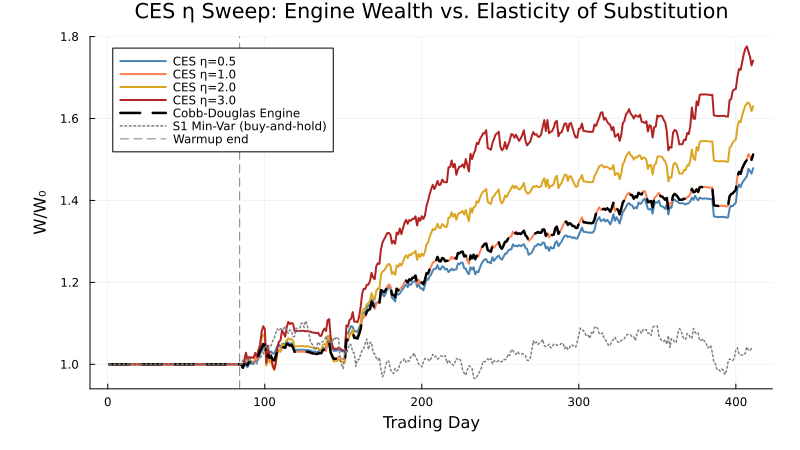

In [19]:
let
    with_warmup(w) = [fill(B₀, offset); w];
    η_values = sort(collect(keys(ces_wealth_curves)));
    palette = [:steelblue, :coral, :goldenrod, :firebrick];

    # --- Step 1: Plot the four CES runs on the full market-day axis (scaled by B₀) ---
    p = plot(size=(800, 450), legend=:topleft,
        title="CES η Sweep: Engine Wealth vs. Elasticity of Substitution",
        xlabel="Trading Day", ylabel="W/W₀",
        left_margin = 10Plots.mm, right_margin = 5Plots.mm,
        top_margin = 3Plots.mm, bottom_margin = 6Plots.mm)
    for (k, η) ∈ enumerate(η_values)
        w_full = with_warmup(ces_wealth_curves[η]);
        plot!(p, 1:length(w_full), w_full ./ B₀,
            label="CES η=$(η)", linewidth=2, color=palette[k])
    end

    # --- Step 2: Overlay the Cobb-Douglas engine and S1 min-var for reference ---
    eng_full = with_warmup(engine_wealth);
    mv_full  = with_warmup(minvar_wealth);
    plot!(p, 1:length(eng_full), eng_full ./ B₀,
        label="Cobb-Douglas Engine", linewidth=2.5, color=:black, linestyle=:dash)
    plot!(p, 1:length(mv_full), mv_full ./ B₀,
        label="S1 Min-Var (buy-and-hold)", linewidth=1.5, color=:gray50, linestyle=:dot)
    vline!(p, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)
    p
end


The code below extends the Task 2 scorecard with one row per CES run, so return, volatility, Sharpe, and drawdown are directly comparable across η values and against the Cobb-Douglas engine and baselines.

In [21]:
let
    # --- Step 1: Risk-free annualized CC growth rate (for excess-growth Sharpe) ---
    rf_horizon_yr = (length(riskfree_wealth) - 1) * Δt;
    rf_growth_pct = log(riskfree_wealth[end] / riskfree_wealth[1]) / rf_horizon_yr * 100;

    # --- Step 2: Metrics for each CES run ---
    η_values = sort(collect(keys(ces_wealth_curves)));
    ces_rows = [scorecard_metrics(ces_wealth_curves[η], "CES Engine (η=$(η))"; rf_growth_pct = rf_growth_pct) for η ∈ η_values];

    # --- Step 3: Append to the existing four-row baseline scorecard ---
    rf_label = "Risk-Free ($(round(g_f*100, digits=2))%)";
    eng = scorecard_metrics(engine_wealth,      "Cobb-Douglas Engine (DD≤15%, τ≤50%)"; rf_growth_pct = rf_growth_pct);
    mv  = scorecard_metrics(minvar_wealth,      "S1 Min-Var (buy-and-hold)";            rf_growth_pct = rf_growth_pct);
    eqw = scorecard_metrics(equalweight_wealth, "Equal-Weight (buy-and-hold)";          rf_growth_pct = rf_growth_pct);
    rf  = scorecard_metrics(riskfree_wealth,    rf_label;                               rf_growth_pct = rf_growth_pct);

    all_rows = vcat([eng], ces_rows, [mv, eqw, rf]);

    # --- Step 4: NPV of terminal wealth, discounted at the risk-free rate, scaled by W₀ ---
    # Each wealth series has its own horizon (length − 1 trading steps), so discount per-series
    # to keep the risk-free row exactly zero (it's compounded and discounted over the same span).
    npv_ratio(w) = (w[end] * exp(-g_f * (length(w) - 1) * Δt) - w[1]) / w[1];
    all_wealths = vcat([engine_wealth],
                       [ces_wealth_curves[η] for η ∈ η_values],
                       [minvar_wealth, equalweight_wealth, riskfree_wealth]);
    npv_col = [round(npv_ratio(w), digits=4) for w ∈ all_wealths];

    # --- Step 5: Build the combined DataFrame ---
    df = DataFrame(
        "Strategy"          => [r[1] for r ∈ all_rows],
        "Growth (%/yr)"     => [r[2] for r ∈ all_rows],
        "Volatility (%/yr)" => [r[3] for r ∈ all_rows],
        "Sharpe Ratio"      => [r[4] for r ∈ all_rows],
        "Max Drawdown (%)"  => [r[5] for r ∈ all_rows],
        "NPV/W₀"            => npv_col,
    );

    println("═"^80)
    println("  SESSION 2 EXTENDED SCORECARD: CES Elasticity Sweep")
    println("═"^80)
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

════════════════════════════════════════════════════════════════════════════════
  SESSION 2 EXTENDED SCORECARD: CES Elasticity Sweep
════════════════════════════════════════════════════════════════════════════════
 ------------------------------------- --------------- ------------------- -------------- ------------------ ---------
                             Strategy   Growth (%/yr)   Volatility (%/yr)   Sharpe Ratio   Max Drawdown (%)    NPV/W₀ 
                               String         Float64             Float64        Float64            Float64   Float64 
 ------------------------------------- --------------- ------------------- -------------- ------------------ ---------
  Cobb-Douglas Engine (DD≤15%, τ≤50%)           31.96               11.87           2.31               4.03    0.4265
                   CES Engine (η=0.5)           30.23               10.92           2.36               3.76     0.395
                   CES Engine (η=1.0)           31.96               11.87

The code below identifies the best and worst η value in the sweep by final `W/W₀`, highlighting the point on the elasticity axis where the engine wins (or loses) the most.

In [23]:
let
    # --- Step 1: Collect terminal W/W₀ by η ---
    η_values = sort(collect(keys(ces_wealth_curves)));
    terminals = [(η, ces_wealth_curves[η][end] / B₀) for η ∈ η_values];

    # --- Step 2: Sort by terminal wealth (descending: best η first) ---
    sort!(terminals, by = x -> x[2], rev = true);

    # --- Step 3: Wide-form ranking DataFrame (rows = η, sorted best → worst) ---
    n_eta = length(terminals);
    ranking_df = DataFrame(
        "Rank"   => 1:n_eta,
        "η"      => [η for (η, _) in terminals],
        "W/W₀"   => [round(w, digits = 3) for (_, w) in terminals],
        "Status" => [i == 1 ? "Best" : (i == n_eta ? "Worst" : "") for i in 1:n_eta],
    );
    println("CES η sweep: ranked by terminal W/W₀")
    pretty_table(ranking_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end;

CES η sweep: ranked by terminal W/W₀
 ------- --------- --------- --------
   Rank         η      W/W₀   Status 
  Int64   Float64   Float64   String 
 ------- --------- --------- --------
      1       3.0     1.741     Best
      2       2.0      1.63
      3       1.0     1.512
      4       0.5     1.479    Worst
 ------- --------- --------- --------


### Adaptive η: Letting the Engine Choose Its Own Elasticity

The static sweep above holds η constant across the entire trading horizon. But the [adaptive elasticity model](eCornell-AI-Finance-S2-Lecture-AI-RebalancingEngine-May-2026.ipynb) links η to the sentiment signal λ: concentrate when neutral, diversify when sentiment is extreme. The engine computes $\eta(\lambda_t) = \eta_{\min} + (\eta_{\max} - \eta_{\min})/(1 + |\lambda_t|)$ at each rebalance day using [the `compute_adaptive_eta(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.compute_adaptive_eta).

In the code block below, we run the engine with `adaptive_eta=true` and return `adaptive_wealth::Vector{Float64}` (the wealth trajectory under adaptive η) and `eta_series::Vector{Float64}` (the per-day η values). A two-panel figure overlays the adaptive run on the static CES sweep (top) and shows the η trajectory (bottom). *(Same frictionless setting as Tasks 1–3.)*

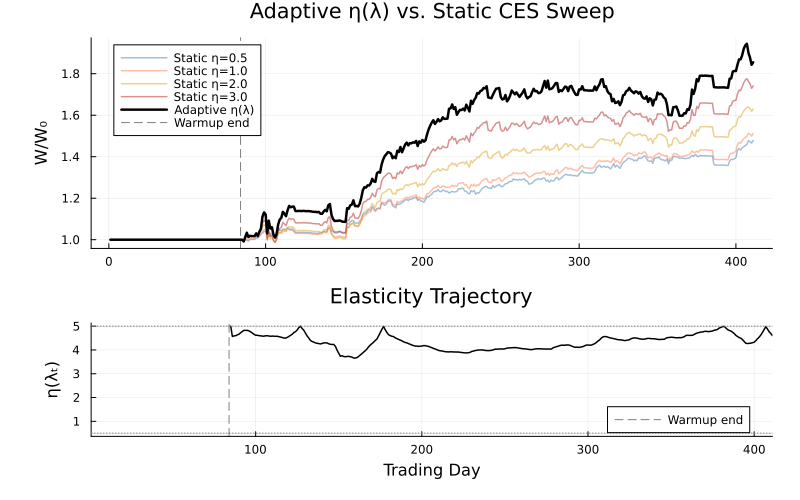

([10000.0, 9917.230300000003, 10125.115855526365, 10336.757495452992, 10132.067262475995, 10190.021369552742, 10172.538341421396, 10175.423341421394, 10172.341441421398, 10306.725317738177  …  18689.196967287404, 18690.44052717423, 18893.228909740137, 19203.071234326493, 19367.984418257107, 19442.906431256673, 19006.353893208357, 18774.209086624072, 18430.26332963128, 18549.819248256663], [5.0, 4.567159259680416, 4.590848228155811, 4.600126953380249, 4.634990260059623, 4.66381201011129, 4.726175523865979, 4.779750022468515, 4.825340506341532, 4.821856380431129  …  4.469472128516292, 4.53920186796421, 4.626147972114674, 4.736277380924345, 4.859243823345015, 4.980516065485095, 4.878753128758747, 4.76749681090085, 4.690823500312209, 4.603049141578647])

In [25]:
adaptive_wealth, eta_series = let
    # --- Step 1: Run the CES engine with adaptive η(λ) ---
    rules = build(MyTriggerRules, (
        max_drawdown = 0.15, max_turnover = 0.50,
        rebalance_schedule = ones(Int, n_trading_days)
    ));
    results_adaptive = run_rebalancing_engine(context, rules, lambda_series;
        offset = offset, allocator = :ces, adaptive_eta = true, eta_bounds = (0.5, 5.0));
    adaptive_wealth = compute_wealth_series(results_adaptive, price_matrix, my_tickers; offset = offset);

    # --- Step 2: Extract the per-day η series for plotting ---
    trading_days = sort(collect(keys(results_adaptive)));
    eta_series = [results_adaptive[d].eta for d in trading_days];

    # --- Step 3: Two-panel plot on the full market-day axis ---
    with_warmup(w) = [fill(B₀, offset); w];
    η_values = sort(collect(keys(ces_wealth_curves)));
    palette = [:steelblue, :coral, :goldenrod, :firebrick];

    # Panel 1: W/W₀ wealth comparison (warmup flat at 1.0)
    p1 = plot(size = (800, 300), legend = :topleft,
        title = "Adaptive η(λ) vs. Static CES Sweep",
        ylabel = "W/W₀",
        left_margin = 10Plots.mm, right_margin = 5Plots.mm,
        top_margin = 3Plots.mm, bottom_margin = 3Plots.mm)
    for (k, η) ∈ enumerate(η_values)
        w_full = with_warmup(ces_wealth_curves[η]);
        plot!(p1, 1:length(w_full), w_full ./ B₀,
            label = "Static η=$(η)", linewidth = 1.5, color = palette[k], alpha = 0.5)
    end
    adapt_full = with_warmup(adaptive_wealth);
    plot!(p1, 1:length(adapt_full), adapt_full ./ B₀,
        label = "Adaptive η(λ)", linewidth = 2.5, color = :black)
    vline!(p1, [offset], linestyle = :dash, color = :black, alpha = 0.5, label = "Warmup end")

    # Panel 2: η(λ) trajectory plotted at post-warmup market-day positions, aligned with Panel 1
    η_days = offset .+ (1:length(eta_series));
    x_max  = length(adapt_full);
    p2 = plot(η_days, eta_series,
        label = "", linewidth = 1.5, color = :black,
        xlabel = "Trading Day", ylabel = "η(λₜ)",
        title = "Elasticity Trajectory", size = (800, 200),
        xlim = (1, x_max),
        left_margin = 10Plots.mm, right_margin = 5Plots.mm,
        top_margin = 3Plots.mm, bottom_margin = 6Plots.mm)
    hline!(p2, [0.5, 5.0], linestyle = :dot, color = :gray50, label = "")
    vline!(p2, [offset], linestyle = :dash, color = :black, alpha = 0.5, label = "Warmup end")

    # --- Step 4: Combine panels, render, and return the two series ---
    p_combined = plot(p1, p2, layout = grid(2, 1, heights = [0.65, 0.35]), size = (800, 500))
    display(p_combined)
    adaptive_wealth, eta_series
end


___
## Epilogue: Stress Test under $\alpha,\beta$ Bootstrap Noise and Per-Trade Cost $c$
Two production frictions compress the engine's performance: $\alpha$ and $\beta$ are point estimates with non-trivial standard errors (the Session 1 bootstrap quantifies the per-ticker SEs), and every rebalance pays the lecture's [per-trade cost $c$](eCornell-AI-Finance-S2-Lecture-AI-RebalancingEngine-May-2026.ipynb) on the realized notional $\sum_i |\Delta n_i|\,P_{i,t}$. This section reintroduces both and sweeps $c \in \{0, 5, 20\}$ bps to read how friction shrinks growth, Sharpe, and NPV simultaneously, not just the headline Sharpe.

We perturb each ticker's $\alpha$ and $\beta$ by independent Gaussian draws scaled to its bootstrap SE from `sim-parameter-estimates.jld2`, then rerun the engine on the same deployment-window price path at three cost levels: 0, 5, and 20 bps per trade. Each (cost, noise) cell averages 30 Monte Carlo draws of the perturbed SIM parameters; prices are held fixed. 

> __What should we see?__
>
> Noisier $\alpha,\beta$ inputs produce noisier preference weights $\gamma_i$ and a compressed Sharpe; per-trade costs erode it further. A Sharpe that stays comfortably positive at 20 bps with full α/β noise says the mechanic is robust on this path; one that collapses says the frictionless number was an artifact of point estimates and zero friction.

In the code block below, we load the bootstrap SE, run the full stress grid, print the summary, and return `stress_results::Dict{Float64, Vector{NamedTuple}}` mapping each cost level to its per-draw metric rows.

In [27]:
stress_results = let
    # --- Step 1: Load bootstrap uncertainty from Session 1 ---
    s1_data = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));
    bs      = s1_data["bootstrap_results"]::Dict{String,Dict{String,Any}};

    # --- Step 2: Stress grid ---
    cost_grid   = [0.0, 5.0, 20.0];   # basis points per trade
    K           = 30;                  # Monte Carlo draws per cost level
    STRESS_SEED = 2026;

    # --- Step 3: Trigger rules and risk-free CC growth benchmark ---
    rules = build(MyTriggerRules, (
        max_drawdown = 0.15, max_turnover = 0.50,
        rebalance_schedule = ones(Int, n_trading_days)
    ));
    rf_horizon_yr = (length(riskfree_wealth) - 1) * Δt;
    rf_growth_pct = log(riskfree_wealth[end] / riskfree_wealth[1]) / rf_horizon_yr * 100;

    # --- Step 4: Helper: one noisy sim_params draw using bootstrap SE for α and β ---
    noisy_params(rng) = Dict(
        t => (α + bs[t]["alpha_std"] * randn(rng),
              β + bs[t]["beta_std"]  * randn(rng),
              σ_ε)
        for (t, (α, β, σ_ε)) ∈ sim_params
    );

    # --- Step 5: Run the full stress grid ---
    rng = MersenneTwister(STRESS_SEED);
    stress_results = Dict{Float64, Vector{NamedTuple}}();
    for cost_bps ∈ cost_grid
        rows = Vector{NamedTuple}();
        for k ∈ 1:K
            np  = noisy_params(rng);
            ctx = build(MyRebalancingContextModel, (
                B = B₀, tickers = my_tickers, marketdata = price_matrix,
                marketfactor = gm_ema, sim_parameters = np,
                lambda = 0.0, Δt = Δt, epsilon = context.epsilon
            ));
            eng_results = run_rebalancing_engine(ctx, rules, lambda_series;
                offset = offset, allocator = :cobb_douglas, cost_bps = cost_bps);
            w = compute_wealth_series(eng_results, price_matrix, my_tickers; offset = offset);
            m = scorecard_metrics(w, "stress"; rf_growth_pct = rf_growth_pct);
            push!(rows, (
                growth    = m[2], vol = m[3], sharpe = m[4], dd = m[5],
                npv_ratio = (w[end] * exp(-g_f * (length(w) - 1) * Δt) - w[1]) / w[1],
            ));
        end
        stress_results[cost_bps] = rows;
    end

    # --- Step 6: Summary statistics per cost level ---
    med(rs, f) = median([r[f] for r ∈ rs]);
    pct(rs, f, q) = quantile([r[f] for r ∈ rs], q);
    rs_by_cost = [stress_results[c] for c ∈ cost_grid];

    summary_df = DataFrame(
        "Cost (bps)"        => cost_grid,
        "Growth (%/yr) med" => [round(med(rs, :growth), digits=2) for rs ∈ rs_by_cost],
        "Growth [5%,95%]"   => ["[$(round(pct(rs, :growth, 0.05), digits=2)), $(round(pct(rs, :growth, 0.95), digits=2))]" for rs ∈ rs_by_cost],
        "Sharpe med"        => [round(med(rs, :sharpe), digits=2) for rs ∈ rs_by_cost],
        "Sharpe [5%,95%]"   => ["[$(round(pct(rs, :sharpe, 0.05), digits=2)), $(round(pct(rs, :sharpe, 0.95), digits=2))]" for rs ∈ rs_by_cost],
        "Max DD (%) med"    => [round(med(rs, :dd), digits=2) for rs ∈ rs_by_cost],
        "NPV/W₀ med"        => [round(med(rs, :npv_ratio), digits=4) for rs ∈ rs_by_cost],
    );

    println("═"^110)
    println("  STRESS TEST: α/β bootstrap noise × transaction cost  (K = $(K) MC draws per cell)")
    println("═"^110)
    pretty_table(summary_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    stress_results
end;

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  STRESS TEST: α/β bootstrap noise × transaction cost  (K = 30 MC draws per cell)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
 ------------ ------------------- ----------------- ------------ ----------------- ---------------- ------------
  Cost (bps)   Growth (%/yr) med   Growth [5%,95%]   Sharpe med   Sharpe [5%,95%]   Max DD (%) med   NPV/W₀ med 
     Float64             Float64            String      Float64            String          Float64      Float64 
 ------------ ------------------- ----------------- ------------ ----------------- ---------------- ------------
         0.0               31.42    [27.77, 34.29]         2.23      [1.84, 2.71]             4.45       0.4167
         5.0               29.16    [23.12, 31.54]         2.08      [1.54, 2.42]             4.83       0.3757
        20.0        

___
## Summary
This example ran the Cobb-Douglas rebalancing engine on the 2025 deployment window with production-style triggers, scored it against passive baselines, swept CES elasticity (static and adaptive), and stress-tested the headline numbers under α/β bootstrap noise and per-trade transaction costs.

> __Key Takeaways:__
>
> * __Drawdown limits act as circuit breakers:__ Tighter drawdown thresholds cause the engine to de-risk to cash earlier, protecting capital at the cost of missing recoveries. Looser thresholds allow more volatility but capture more upside.
> * __CES elasticity tunes conviction:__ The same preference weights drive different wealth paths depending on the elasticity value. Higher elasticity concentrates budget in the top-ranked asset and amplifies both gains and losses.
> * __Adaptive elasticity adds a second adaptive channel:__ Linking the elasticity to the sentiment signal lets the engine concentrate when sentiment is neutral and diversify when sentiment is extreme. Session 3 revisits this choice using multi-armed bandits that learn the best elasticity per regime from data.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The rebalancing engine described here is a pedagogical tool; real-world algorithmic trading involves regulatory requirements, execution risk, and operational considerations beyond the scope of this session.

___